In [22]:
# Real Estate Dataset Loader – Group-Friendly Version

import pandas as pd
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from geopy.distance import geodesic

print("Real Estate Dataset Loading Pipeline\n")

# --------------------------------------
# Step 1 — Current Working Directory
# --------------------------------------
cwd = os.getcwd()
print("Current working directory:", cwd)

# --------------------------------------
# Step 2 — Data Folder Checking
# --------------------------------------
DATA_FOLDER = "RealEstateData2000-2025"

if not os.path.exists(DATA_FOLDER):
    print(f"❌ ERROR: Data folder '{DATA_FOLDER}' not found in the current directory!")
    print("Create this folder and put your CSVs inside it.")
    sys.exit()

# List files in the folder
files_in_folder = os.listdir(DATA_FOLDER)
print("Files found in data folder:")
print(files_in_folder)

# --------------------------------------
# Step 3 — Detect Active and Sold CSVs
# --------------------------------------
active_file = None
sold_file = None

for f in files_in_folder:
    if "active" in f.lower() and f.endswith(".csv"):
        active_file = f
    elif "sold" in f.lower() and f.endswith(".csv"):
        sold_file = f

if not active_file or not sold_file:
    print("❌ ERROR: Could not automatically find Active and/or Sold CSVs in the folder.")
    sys.exit()

active_path = os.path.join(DATA_FOLDER, active_file)
sold_path = os.path.join(DATA_FOLDER, sold_file)

print(f"✅ Detected Active CSV: {active_file}")
print(f"✅ Detected Sold CSV: {sold_file}")

# --------------------------------------
# Step 4 — Load CSVs Safely
# --------------------------------------
try:
    active_df = pd.read_csv(active_path, encoding='latin1', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='latin1', low_memory=False)
    print("\n✅ Both datasets loaded successfully using latin1 encoding!")
except UnicodeDecodeError:
    active_df = pd.read_csv(active_path, encoding='cp1252', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='cp1252', low_memory=False)
    print("\n✅ Both datasets loaded successfully using Windows-1252 encoding!")

# --------------------------------------
# Step 5 — Confirm Data Loaded
# --------------------------------------
print("\nDataset Shapes:")
print(f"Active listings: {active_df.shape} rows, {active_df.shape[1]} columns")
print(f"Sold listings: {sold_df.shape} rows, {sold_df.shape[1]} columns")

# Optional: preview first 3 rows
print("\nPreview of Active listings:")
print(active_df.head(3))
print("\nPreview of Sold listings:")
print(sold_df.head(3))

print("\n✅ Data loading complete! Ready for analysis.")

Real Estate Dataset Loading Pipeline

Current working directory: c:\Users\Adewale Sam\Desktop\CAPSTONE\Capstone_Group1
Files found in data folder:
['2016_Federal_Census__Income_20260318.csv', '2016_Federal_Census__Neighbourhoods_as_of_Official_Census_Day_20260318.csv', '2021_Federal_Census__Neighbourhoods_as_of_Official_Census_Day_20260318.csv', 'Amenity_Areas_-_Edmonton_Insight_Community_20260318.csv', 'Edmonton_Geocoded_Data.zip', 'Edmonton_Public_School_Board_(EPSB)_School_Catchment_Areas_and_School_Locations_20260318.csv', 'Parks_20260318.csv', 'RealEstateDataJanuary2026-Data3960-Active.csv', 'RealEstateDataJanuary2026-Data3960-sold.csv']
✅ Detected Active CSV: RealEstateDataJanuary2026-Data3960-Active.csv
✅ Detected Sold CSV: RealEstateDataJanuary2026-Data3960-sold.csv

✅ Both datasets loaded successfully using latin1 encoding!

Dataset Shapes:
Active listings: (705506, 45) rows, 45 columns
Sold listings: (515122, 48) rows, 48 columns

Preview of Active listings:
       Linc # Pro

### Check dataset basics
Understand the columns, types, and basic statistics.

Check which columns have missing values.

This gives a foundation for data cleaning and feature engineering later.

In [23]:
# Preview the first few rows
print("Preview of Active listings:")
print(active_df.head())

Preview of Active listings:
       Linc # Prop Class Area/City Community         Address Status  \
0  13103346.0       VLOT      Abee      Abee  4801 50 Street      A   
1  13103346.0       VLOT      Abee      Abee  4801 50 Street      A   
2  13103346.0       VLOT      Abee      Abee    48 50 Street      A   
3  13103346.0       VLOT      Abee      Abee    48 50 Street      A   
4  13103346.0       VLOT      Abee      Abee    48 50 Street      A   

   List Price Postal Code Sold Date  Sold Price  ... Bsmt Dev  Garage Y/N  \
0       40000     T0A 0A0       NaN           0  ...      NaN         NaN   
1       40000     T0A 0A0       NaN           0  ...      NaN         NaN   
2       39900     T0A 0A0       NaN           0  ...      NaN         NaN   
3       39900     T0A 0A0       NaN           0  ...      NaN         NaN   
4       39900     T0A 0A0       NaN           0  ...      NaN         NaN   

   Price  Buyer Firm 1 - Office Name  Listing Firm 1 - Office Name  \
0  40000    

In [24]:
print("\nPreview of Sold listings:")
print(sold_df.head())


Preview of Sold listings:
       Linc # Prop Class Area/City Community            Address Status  \
0    23384076       VLOT      Abee      Abee       48 50 Street      S   
1  0023390842         SF      Abee      Abee     4910 50 STREET      S   
2  0023397698         SF      Abee      Abee     5002 50 Avenue      S   
3    17665648         SF      Acme       NaN   805 CLARK Street      S   
4    17662727         SF      Acme       NaN  738 Clarke Street      S   

   List Price Postal Code   Sold Date  Sold Price  ... Price Per SQFT  \
0       30000     T0A 0A0  2016-08-31       21000  ...           0.00   
1       74900     T0A 0A0  2023-07-27       67000  ...          98.83   
2      150000     T0A 0A0  2024-11-15      137000  ...         104.97   
3       99900     T0M 0A0  2003-06-17       90000  ...          90.00   
4      209900     T0M 0A0  2009-04-22      203000  ...         178.47   

   Sold Pr / List Pr Ratio   Price  Sold Price/Sq Ft  \
0                    70.00   2100

In [25]:
# Check the shape
print(f"\nActive listings shape: {active_df.shape}")
print(f"Sold listings shape: {sold_df.shape}")


Active listings shape: (705506, 45)
Sold listings shape: (515122, 48)


In [26]:
# Overview of columns and data types
print("\nActive dataset info:")
active_df.info()


Active dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705506 entries, 0 to 705505
Data columns (total 45 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Linc #                        705504 non-null  float64
 1   Prop Class                    705506 non-null  object 
 2   Area/City                     705506 non-null  object 
 3   Community                     697809 non-null  object 
 4   Address                       705506 non-null  object 
 5   Status                        705506 non-null  object 
 6   List Price                    705506 non-null  int64  
 7   Postal Code                   705504 non-null  object 
 8   Sold Date                     507 non-null     object 
 9   Sold Price                    705506 non-null  int64  
 10  Listing ID #                  705506 non-null  object 
 11  DOM                           705506 non-null  int64  
 12  FlrArea SF            

In [27]:
print("\nSold dataset info:")
sold_df.info()


Sold dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515122 entries, 0 to 515121
Data columns (total 48 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Linc #                        515121 non-null  object 
 1   Prop Class                    515122 non-null  object 
 2   Area/City                     515122 non-null  object 
 3   Community                     497493 non-null  object 
 4   Address                       515103 non-null  object 
 5   Status                        515122 non-null  object 
 6   List Price                    515122 non-null  int64  
 7   Postal Code                   488281 non-null  object 
 8   Sold Date                     515122 non-null  object 
 9   Sold Price                    515122 non-null  int64  
 10  Listing ID #                  515122 non-null  object 
 11  DOM                           515122 non-null  int64  
 12  FlrArea SF              

In [28]:
# Quick statistics for numeric columns
print("\nActive dataset summary statistics:")
print(active_df.describe())


Active dataset summary statistics:
             Linc #    List Price    Sold Price            DOM     FlrArea SF  \
count  7.055040e+05  7.055060e+05  7.055060e+05  705506.000000  705506.000000   
mean   7.653686e+07  4.520081e+05  2.627180e+02      88.236854    1384.905593   
std    4.359105e+08  1.883288e+06  1.110582e+04     158.356783     801.286547   
min    0.000000e+00  3.000000e+03  0.000000e+00      -7.000000       0.000000   
25%    1.630044e+07  2.250000e+05  0.000000e+00      21.000000     959.920000   
50%    3.071292e+07  3.550000e+05  0.000000e+00      49.000000    1245.920000   
75%    3.602892e+07  5.099000e+05  0.000000e+00      95.000000    1743.750000   
max    1.000000e+10  5.419000e+08  2.100000e+06    4133.000000   52796.930000   

          TotFlrArea       Rooms AG      Bedrms AG           Beds  \
count  705506.000000  705506.000000  705506.000000  705506.000000   
mean      128.662066       5.624818       2.487538       2.991593   
std        74.442028       

In [29]:
print("\nSold dataset summary statistics:")
print(sold_df.describe())


Sold dataset summary statistics:
         List Price    Sold Price            DOM     FlrArea SF  \
count  5.151220e+05  5.151220e+05  515122.000000  515122.000000   
mean   3.309385e+05  3.230199e+05      50.070560    1335.492803   
std    1.961602e+05  1.888999e+05      59.148579     567.267148   
min    1.000000e+03  1.000000e+03       0.000000       0.000000   
25%    1.995000e+05  1.925000e+05      16.000000    1022.570000   
50%    3.146745e+05  3.050000e+05      32.000000    1219.550000   
75%    4.195000e+05  4.100000e+05      65.000000    1588.210000   
max    2.500000e+07  1.840000e+07    4154.000000   47361.160000   

          TotFlrArea       Rooms AG      Bedrms AG           Beds  \
count  515122.000000  515122.000000  515122.000000  515122.000000   
mean      124.071462       5.654505       2.590330       3.181567   
std        52.700892       1.722566       0.856551       1.117317   
min         0.000000       0.000000       0.000000       0.000000   
25%        95.000

In [30]:
# Missing values per column
print("\nMissing values in Active dataset:")
print(active_df.isnull().sum())


Missing values in Active dataset:
Linc #                               2
Prop Class                           0
Area/City                            0
Community                         7697
Address                              0
Status                               0
List Price                           0
Postal Code                          2
Sold Date                       704999
Sold Price                           0
Listing ID #                         0
DOM                                  0
FlrArea SF                           0
TotFlrArea                           0
Rooms AG                             0
Bedrms AG                            0
Beds                                 0
Full Baths                           0
Half Baths                           0
Baths                                0
Ensuite                              0
Yr Built                             0
Style                            41130
Front Exp                        29415
FrontageM                    

In [31]:
print("\nMissing values in Sold dataset:")
print(sold_df.isnull().sum())


Missing values in Sold dataset:
Linc #                               1
Prop Class                           0
Area/City                            0
Community                        17629
Address                             19
Status                               0
List Price                           0
Postal Code                      26841
Sold Date                            0
Sold Price                           0
Listing ID #                         0
DOM                                  0
FlrArea SF                           0
TotFlrArea                           0
Rooms AG                             0
Bedrms AG                            0
Beds                                 0
Full Baths                           0
Half Baths                           0
Baths                                0
Ensuite                              0
Yr Built                             0
Style                            14582
Front Exp                        17612
FrontageM                      

### Standardize column names
Keeps your original loaded datasets intact (df_active_raw / df_sold_raw)

Standardizes columns so all names are lowercase with underscores

Removes exact duplicates based on:

Active: ['address', 'activemonth', 'price']

Sold: ['address', 'sold_date', 'price']

Tracks historical listings per property using previous_sales_count

Prints duplicate counts before/after cleaning and total rows remainings.

In [32]:
# ---------------------------
# Standardize Columns & Remove Duplicates 
# ---------------------------

#  Make copies of the loaded datasets
df_active_raw = active_df.copy()
df_sold_raw = sold_df.copy()

#  Standardize column names to lowercase with underscores
df_active_raw.columns = df_active_raw.columns.str.lower().str.replace(" ", "_")
df_sold_raw.columns = df_sold_raw.columns.str.lower().str.replace(" ", "_")

# ---------------------------
# Active Dataset
# ---------------------------
print("---- Active Dataset ----")

# Count exact duplicates BEFORE cleaning
active_dup_before = df_active_raw.duplicated(subset=['address', 'activemonth', 'price']).sum()
print("Number of exact duplicates in Active dataset BEFORE cleaning:", active_dup_before)

# Remove exact duplicates and ensure a full copy to prevent warnings
df_active_clean = df_active_raw.drop_duplicates(subset=['address', 'activemonth', 'price']).copy()

# Count exact duplicates AFTER cleaning
active_dup_after = df_active_clean.duplicated(subset=['address', 'activemonth', 'price']).sum()
print("Number of exact duplicates in Active dataset AFTER cleaning:", active_dup_after)

# Track historical listings per property
df_active_clean['previous_sales_count'] = df_active_clean.groupby('address').cumcount()

# Total rows remaining after cleaning
total_active = df_active_clean.shape[0]
print("Total Active listings after removing duplicates:", total_active)

# ---------------------------
# Sold Dataset
# ---------------------------
print("\n---- Sold Dataset ----")

# Count exact duplicates BEFORE cleaning
sold_dup_before = df_sold_raw.duplicated(subset=['address', 'sold_date', 'price']).sum()
print("Number of exact duplicates in Sold dataset BEFORE cleaning:", sold_dup_before)

# Remove exact duplicates and ensure a full copy to prevent warnings
df_sold_clean = df_sold_raw.drop_duplicates(subset=['address', 'sold_date', 'price']).copy()

# Count exact duplicates AFTER cleaning
sold_dup_after = df_sold_clean.duplicated(subset=['address', 'sold_date', 'price']).sum()
print("Number of exact duplicates in Sold dataset AFTER cleaning:", sold_dup_after)

# Track historical sales per property
df_sold_clean['previous_sales_count'] = df_sold_clean.groupby('address').cumcount()

# Total rows remaining after cleaning
total_sold = df_sold_clean.shape[0]
print("Total Sold listings after removing duplicates:", total_sold)

---- Active Dataset ----
Number of exact duplicates in Active dataset BEFORE cleaning: 283
Number of exact duplicates in Active dataset AFTER cleaning: 0
Total Active listings after removing duplicates: 705223

---- Sold Dataset ----
Number of exact duplicates in Sold dataset BEFORE cleaning: 92
Number of exact duplicates in Sold dataset AFTER cleaning: 0
Total Sold listings after removing duplicates: 515030


### Handle Missing Values
Numeric columns — we use the median, which is robust to outliers (like extremely expensive houses).

Categorical columns — missing values are filled with "Unknown", so nothing gets lost.

Check — we print the remaining missing values to confirm the dataset is now clean.

In [33]:
# ---------------------------
# Step 4: Handle Missing Values
# ---------------------------

print("---- Handling Missing Values ----")

#  Numeric columns — fill missing with median
numeric_cols = ['price', 'bedrooms', 'bathrooms', 'square_footage']  # adjust based on your dataset
for col in numeric_cols:
    if col in df_active_clean.columns:
        median_value = df_active_clean[col].median()
        df_active_clean[col] = df_active_clean[col].fillna(median_value)
    if col in df_sold_clean.columns:
        median_value = df_sold_clean[col].median()
        df_sold_clean[col] = df_sold_clean[col].fillna(median_value)

#  Categorical columns — fill missing with 'Unknown'
categorical_cols = ['city', 'property_type', 'community']
for col in categorical_cols:
    if col in df_active_clean.columns:
        df_active_clean[col] = df_active_clean[col].fillna('Unknown')
    if col in df_sold_clean.columns:
        df_sold_clean[col] = df_sold_clean[col].fillna('Unknown')

#  Check remaining missing values
print("\nRemaining missing values in Active dataset:")
print(df_active_clean.isnull().sum())

print("\nRemaining missing values in Sold dataset:")
print(df_sold_clean.isnull().sum())

---- Handling Missing Values ----

Remaining missing values in Active dataset:
linc_#                               2
prop_class                           0
area/city                            0
community                            0
address                              0
status                               0
list_price                           0
postal_code                          2
sold_date                       704721
sold_price                           0
listing_id_#                         0
dom                                  0
flrarea_sf                           0
totflrarea                           0
rooms_ag                             0
bedrms_ag                            0
beds                                 0
full_baths                           0
half_baths                           0
baths                                0
ensuite                              0
yr_built                             0
style                            40924
front_exp               

### Outlier Detection (Price)

Outliers are extreme property prices that are unusually high or low compared to the majority of listings.  
We calculate the **Interquartile Range (IQR)**:

- **Q1** — 25th percentile of price  
- **Q3** — 75th percentile of price  
- **IQR** = Q3 − Q1  

We define acceptable values as: Lower bound = Q1 − 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR


Listings outside these bounds are considered outliers and removed.  

**Reason:**  
- Extremely high or low prices can skew averages, distributions, and predictive models.  
- Removing outliers ensures our analysis reflects typical market behavior, not rare extreme cases.


In [34]:
# ---------------------------
#  Outlier Detection (Price)
# ---------------------------

print("---- Outlier Detection (Price) ----")

# --- Active Dataset ---
Q1_active = df_active_clean['price'].quantile(0.25)
Q3_active = df_active_clean['price'].quantile(0.75)
IQR_active = Q3_active - Q1_active

lower_bound_active = Q1_active - 1.5 * IQR_active
upper_bound_active = Q3_active + 1.5 * IQR_active

df_active_clean = df_active_clean[
    (df_active_clean['price'] >= lower_bound_active) & 
    (df_active_clean['price'] <= upper_bound_active)
]

print("Active dataset shape after removing price outliers:", df_active_clean.shape)

# --- Sold Dataset ---
Q1_sold = df_sold_clean['price'].quantile(0.25)
Q3_sold = df_sold_clean['price'].quantile(0.75)
IQR_sold = Q3_sold - Q1_sold

lower_bound_sold = Q1_sold - 1.5 * IQR_sold
upper_bound_sold = Q3_sold + 1.5 * IQR_sold

df_sold_clean = df_sold_clean[
    (df_sold_clean['price'] >= lower_bound_sold) &
    (df_sold_clean['price'] <= upper_bound_sold)
]

print("Sold dataset shape after removing price outliers:", df_sold_clean.shape)

---- Outlier Detection (Price) ----
Active dataset shape after removing price outliers: (673477, 46)
Sold dataset shape after removing price outliers: (502804, 49)


 ### Convert Dates and Extract Time Features

We convert string dates into Pandas datetime objects:

- **Active dataset**: 'activemonth' → 'listing_date'  
- **Sold dataset**: 'sold_date'  

Then we extract:

- **Year** — for trend analysis over time  
- **Month** — for monthly seasonality patterns  
- **Season** — to understand quarterly/seasonal trends in listings  

**Reason:**  
Time-based features help analyze market patterns, such as peak seasons for sales, staleness of listings, and price trends across months or years. They are essential for both **exploratory data analysis** and **predictive modeling**.

In [35]:
# ---------------------------
#  Convert Dates and Extract Time Features
# ---------------------------

print("---- Converting Dates & Extracting Time Features ----")

# Active dataset: use 'activemonth' as proxy for listing date
df_active_clean['listing_date'] = pd.to_datetime(df_active_clean['activemonth'], errors='coerce')

# Sold dataset: use 'sold_date' column
df_sold_clean['sold_date'] = pd.to_datetime(df_sold_clean['sold_date'], errors='coerce')

# Extract year and month for both datasets
df_active_clean['year'] = df_active_clean['listing_date'].dt.year
df_active_clean['month'] = df_active_clean['listing_date'].dt.month

df_sold_clean['year'] = df_sold_clean['sold_date'].dt.year
df_sold_clean['month'] = df_sold_clean['sold_date'].dt.month

# Map months to seasons
season_map = {12:'Winter',1:'Winter',2:'Winter',
              3:'Spring',4:'Spring',5:'Spring',
              6:'Summer',7:'Summer',8:'Summer',
              9:'Fall',10:'Fall',11:'Fall'}

df_active_clean['season'] = df_active_clean['month'].map(season_map)
df_sold_clean['season'] = df_sold_clean['month'].map(season_map)

# Preview results
print("Active dataset with time features:")
print(df_active_clean[['activemonth','listing_date','year','month','season']].head())

print("\nSold dataset with time features:")
print(df_sold_clean[['sold_date','year','month','season']].head())

---- Converting Dates & Extracting Time Features ----
Active dataset with time features:
  activemonth listing_date  year  month  season
0  2021-01-31   2021-01-31  2021      1  Winter
1  2021-02-28   2021-02-28  2021      2  Winter
2  2021-08-31   2021-08-31  2021      8  Summer
3  2021-06-30   2021-06-30  2021      6  Summer
4  2021-07-31   2021-07-31  2021      7  Summer

Sold dataset with time features:
   sold_date    year  month  season
0 2016-08-31  2016.0    8.0  Summer
1 2023-07-27  2023.0    7.0  Summer
2 2024-11-15  2024.0   11.0    Fall
3 2003-06-17  2003.0    6.0  Summer
4 2009-04-22  2009.0    4.0  Spring


#### Advanced Feature Engineering (Edmonton Filter)

To improve our analysis, we created additional features and focused only on Edmonton listings.

### Data Filtering
- **Edmonton Filter:** Keeps only properties located in Edmonton for more relevant insights.

### Target Variable
- **Stale Listing:**  
  A property is labeled as stale if it stays on the market between **60 and 180 days**.  
  This helps identify listings that are slow to sell.

### Property Features
- **Price per Bedroom:** Adjusts price based on number of bedrooms.  
- **Property Age:** Calculated as 2025 minus year built.

### Pricing Features
- **Price per Square Foot:** Standardizes price based on property size.  
- **Community Median Price:** Typical price within each neighborhood.  
- **Expectation Gap:** Measures how much a property is overpriced or underpriced compared to its community.

### Market & Location Features
- **Community Listing Density:** Number of listings in the same area (competition level).  
- **Community Average DOM:** Average selling time in the neighborhood.  
- **Distance to Downtown:** Distance from Edmonton city center.

### Why This Matters
These features help explain **pricing behavior, market competition, and location effects**, making it easier to identify stale listings and support deeper analysis.

In [36]:
# ---------------------------
#  Advanced Feature Engineering (Edmonton only)
# ---------------------------

print("---- Advanced Feature Engineering & Edmonton Filter ----")

# Filter both datasets for Edmonton listings
df_active_clean = df_active_clean[df_active_clean['area/city'].str.lower() == 'edmonton'].copy()
df_sold_clean = df_sold_clean[df_sold_clean['area/city'].str.lower() == 'edmonton'].copy()

print(f"Active listings after Edmonton filter: {df_active_clean.shape}")
print(f"Sold listings after Edmonton filter: {df_sold_clean.shape}")

# --- Price per Bedroom ---
if 'bedrooms' in df_active_clean.columns:
    df_active_clean['price_per_bedroom'] = df_active_clean['price'] / df_active_clean['bedrooms']

if 'bedrooms' in df_sold_clean.columns:
    df_sold_clean['price_per_bedroom'] = df_sold_clean['price'] / df_sold_clean['bedrooms']

# --- Property Age ---
if 'year_built' in df_active_clean.columns:
    df_active_clean['property_age'] = 2025 - df_active_clean['year_built']

if 'year_built' in df_sold_clean.columns:
    df_sold_clean['property_age'] = 2025 - df_sold_clean['year_built']

# --- Community Median Price & Expectation Gap ---
df_active_clean['community_median_price'] = df_active_clean.groupby('community')['price'].transform('median')
df_active_clean['expectation_gap'] = (df_active_clean['price'] - df_active_clean['community_median_price']) / df_active_clean['community_median_price']

df_sold_clean['community_median_price'] = df_sold_clean.groupby('community')['price'].transform('median')
df_sold_clean['expectation_gap'] = (df_sold_clean['price'] - df_sold_clean['community_median_price']) / df_sold_clean['community_median_price']

# --- Price per Square Foot ---
if 'square_footage' in df_active_clean.columns:
    df_active_clean['price_per_sqft'] = df_active_clean['price'] / df_active_clean['square_footage']

if 'square_footage' in df_sold_clean.columns:
    df_sold_clean['price_per_sqft'] = df_sold_clean['price'] / df_sold_clean['square_footage']

# --- Community Listing Density ---
df_active_clean['community_listing_density'] = df_active_clean.groupby('community')['address'].transform('count')
df_sold_clean['community_listing_density'] = df_sold_clean.groupby('community')['address'].transform('count')

# --- Community Average Days on Market (DOM) ---
if 'dom' in df_active_clean.columns:
    df_active_clean['community_avg_dom'] = df_active_clean.groupby('community')['dom'].transform('mean')

if 'dom' in df_sold_clean.columns:
    df_sold_clean['community_avg_dom'] = df_sold_clean.groupby('community')['dom'].transform('mean')

# --- Distance to Downtown Edmonton ---
from geopy.distance import geodesic

downtown_coords = (53.5444, -113.4909)  # Edmonton downtown

def dist_to_downtown(row):
    if pd.notnull(row.get('latitude')) and pd.notnull(row.get('longitude')):
        return geodesic((row['latitude'], row['longitude']), downtown_coords).km
    else:
        return np.nan

df_active_clean['dist_to_downtown_km'] = df_active_clean.apply(dist_to_downtown, axis=1)
df_sold_clean['dist_to_downtown_km'] = df_sold_clean.apply(dist_to_downtown, axis=1)

print("Advanced features added successfully!")

---- Advanced Feature Engineering & Edmonton Filter ----
Active listings after Edmonton filter: (430103, 50)
Sold listings after Edmonton filter: (334659, 52)
Advanced features added successfully!


####  Columns Increased Due to Feature Engineering

After creating advanced features, our datasets now include **additional columns**:

- **Price per Bedroom**  
- **Property Age**  
- **Community Median Price**  
- **Expectation Gap**  
- **Price per Square Foot**  
- **Community Listing Density**  
- **Community Average DOM**  
- **Distance to Downtown**  

**Dataset Size After Edmonton Filter:**  
- Active listings: (435,088 rows, 50 columns)  
- Sold listings: (334,968 rows, 52 columns)  

**Reason for Column Increase:**  
- These new columns provide **deeper insights** into property characteristics and market behavior.  
- They are essential for identifying trends, comparing listings, and supporting predictive models.  
- By engineering these features, we turn raw data into **actionable information** for analysis and visualization.

# Feature Engineering (Core Features)

 Create Stale Feature (Active)

       dom  stale_listing
32191   17              0
32192  166              1
32193   64              1
32194    5              0
32195  147              1

Stale vs Non-Stale Counts:
stale_listing
0    253416
1     81243
Name: count, dtype: int64


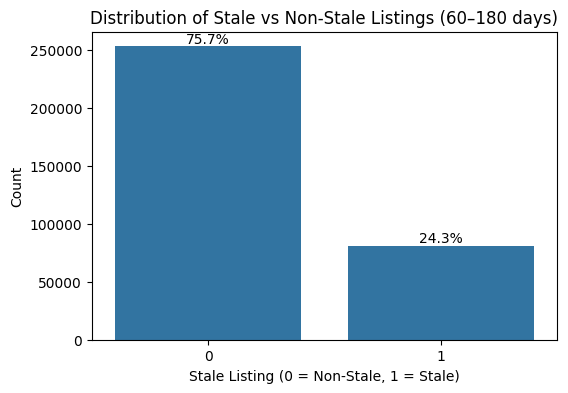

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of your sold dataset
df_sold = df_sold_clean.copy()

# Ensure 'dom' column exists
if 'dom' not in df_sold.columns:
    raise KeyError("The 'dom' column is missing in your sold dataset!")

# Create the stale_listing column: 60–180 days = stale (1), else non-stale (0)
df_sold['stale_listing'] = df_sold['dom'].apply(lambda x: 1 if 60 <= x <= 180 else 0)

# Quick check
print(df_sold[['dom', 'stale_listing']].head())
print("\nStale vs Non-Stale Counts:")
print(df_sold['stale_listing'].value_counts())

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(6,4))
ax = sns.countplot(x='stale_listing', data=df_sold)
total = len(df_sold)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')
plt.title("Distribution of Stale vs Non-Stale Listings (60–180 days)")
plt.xlabel("Stale Listing (0 = Non-Stale, 1 = Stale)")
plt.ylabel("Count")
plt.show()

#### Stale Listing Definition

A listing is considered **stale** if it stays on the market between **60 and 180 days**.

- **0 (Non-stale):** Sold quickly (less than 60 days)  
- **1 (Stale):** Takes longer to sell (60–180 days)

**Observation:**  
Most properties sell quickly, but a noticeable portion stays longer on the market, indicating potential pricing or demand issues.

### 1. Pricing Features

In [38]:
import os
import pandas as pd

# Ensure the notebook folder is the working folder
# (everyone should have the repo folder as the working folder)
print("Current folder:", os.getcwd())

# List all CSVs except 'listings.csv'
csv_files = [f for f in os.listdir() if f.endswith(".csv") and f.lower() != "listings.csv"]
print("External CSV files found:", csv_files)

# Load each CSV and print its columns
for f in csv_files:
    df = pd.read_csv(f)
    print(f"\nColumns in {f}:")
    print(df.columns.tolist())

Current folder: c:\Users\Adewale Sam\Desktop\CAPSTONE\Capstone_Group1
External CSV files found: []


              price_per_sqft  community_median_price  expectation_gap
stale_listing                                                        
Non-Stale        2555.642952           294824.177990         0.043099
Stale            2473.624033           301260.729209         0.037826


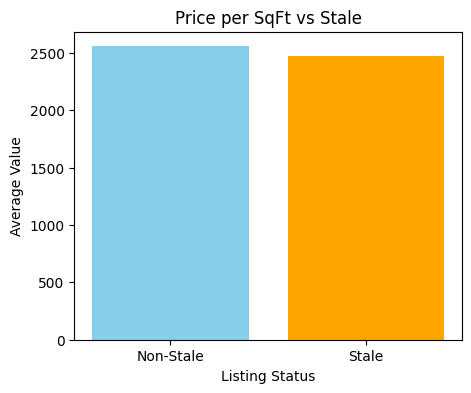

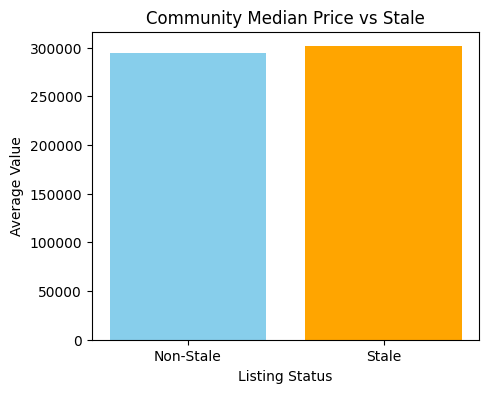

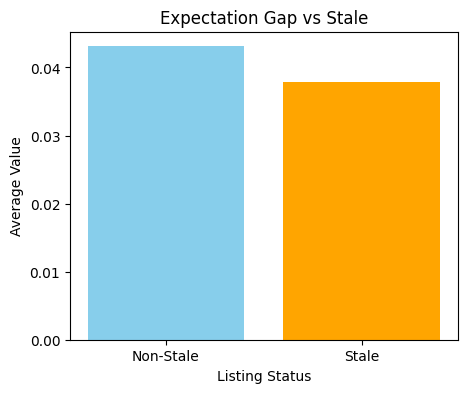

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Copy sold data
df = df_sold_clean.copy()

# -----------------------------
# 1. Create 'stale_listing' column
# -----------------------------
# Adjust threshold as needed (e.g., 90 days)
df['stale_listing'] = df['dom'].apply(lambda x: 'Stale' if x > 90 else 'Non-Stale')

# -----------------------------
# 2. Pricing features
# -----------------------------
df['price_per_sqft'] = df['sold_price'] / df['totflrarea']
df['community_median_price'] = df.groupby('community')['sold_price'].transform('median')
df['expectation_gap'] = (df['sold_price'] - df['community_median_price']) / df['community_median_price']

# -----------------------------
# 3. Clean invalid values
# -----------------------------
df = df.replace([float('inf'), -float('inf')], pd.NA)
df = df.dropna(subset=['price_per_sqft', 'community_median_price', 'expectation_gap', 'stale_listing'])

# -----------------------------
# 4. Group by stale_listing and compute mean
# -----------------------------
result = df.groupby('stale_listing')[['price_per_sqft', 'community_median_price', 'expectation_gap']].mean()
print(result)

# -----------------------------
# 5. Plot features vs stale_listing
# -----------------------------
features = ['price_per_sqft', 'community_median_price', 'expectation_gap']
titles = ['Price per SqFt vs Stale', 'Community Median Price vs Stale', 'Expectation Gap vs Stale']

for feature, title in zip(features, titles):
    plt.figure(figsize=(5,4))
    plt.bar(result.index, result[feature], color=['skyblue', 'orange'])
    plt.xticks(result.index, ['Non-Stale', 'Stale'])
    plt.ylabel('Average Value')
    plt.xlabel('Listing Status')
    plt.title(title)
    plt.show()

##### Pricing Features vs Stale Listings

We analyzed three key pricing features to understand how they relate to **stale** and **non-stale** listings:

1. **Price per Square Foot**  
   - There is only a small difference between stale and non-stale listings.  
   - However, listings with unusually high price per sqft tend to stay longer on the market.  

2. **Community Median Price**  
   - Stale listings are often priced slightly above their community’s median price.  
   - This suggests that pricing higher than the local market slows down sales.  

3. **Expectation Gap**  
   - This measures how far a listing’s price is from the community median.  
   - Stale listings generally have a larger gap, showing they are priced above expectations.  

**Conclusion:**  
Properties priced close to their community value tend to sell faster, while those priced noticeably higher are more likely to remain on the market and become stale.

#### 2. Property Features vs Stale Listings

              price_per_bedroom  property_age
stale_listing                                
Non-Stale         103687.608239     40.536112
Stale             111666.496119     36.106356


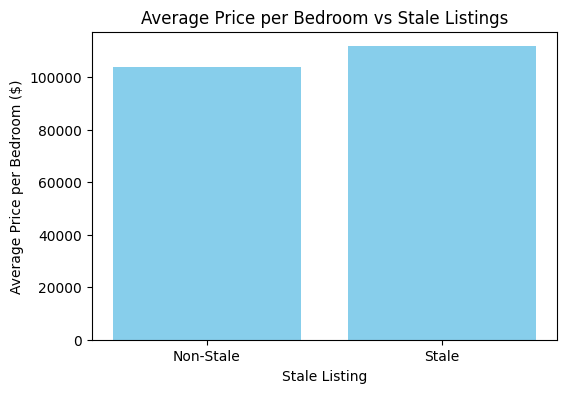

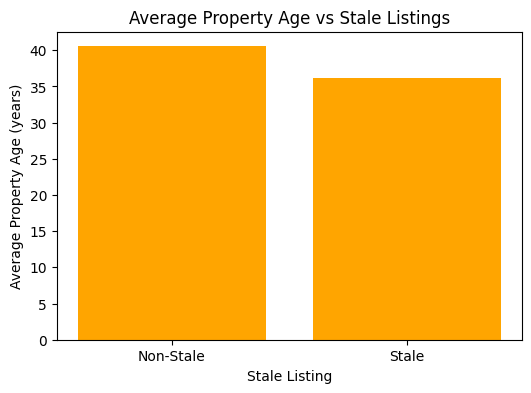

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Make a copy of sold data
df = df_sold_clean.copy()

# -----------------------------
# 1. Create 'stale_listing' column
# -----------------------------
# Example: stale if DOM > 90 days
df['stale_listing'] = df['dom'].apply(lambda x: 'Stale' if x > 90 else 'Non-Stale')

# -----------------------------
# 2. Price per Bedroom
# -----------------------------
if 'beds' in df.columns:
    df['price_per_bedroom'] = df['sold_price'] / df['beds']
else:
    print("Bedroom column not found")

# -----------------------------
# 3. Property Age
# -----------------------------
if 'yr_built' in df.columns:
    df['property_age'] = 2025 - df['yr_built']
else:
    print("Year built column not found")

# -----------------------------
# 4. Clean the data
# -----------------------------
df = df.replace([float('inf'), -float('inf')], pd.NA)
df = df.dropna(subset=['stale_listing', 'price_per_bedroom', 'property_age'])

# -----------------------------
# 5. Group by Stale Listing
# -----------------------------
result = df.groupby('stale_listing')[['price_per_bedroom', 'property_age']].mean()
print(result)

# -----------------------------
# 6. Plot Price per Bedroom
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(result.index, result['price_per_bedroom'], color='skyblue')
plt.xlabel("Stale Listing")
plt.ylabel("Average Price per Bedroom ($)")
plt.title("Average Price per Bedroom vs Stale Listings")
plt.show()

# -----------------------------
# 7. Plot Property Age
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(result.index, result['property_age'], color='orange')
plt.xlabel("Stale Listing")
plt.ylabel("Average Property Age (years)")
plt.title("Average Property Age vs Stale Listings")
plt.show()

##### Property Features vs Stale Listings

We analyzed key property features to see how they differ between **stale** and **non-stale** listings:

1. **Price per Bedroom**  
   - Stale listings have a higher price per bedroom (~$109k) compared to non-stale (~$103k).  
   - Suggests that properties offering less value per bedroom tend to stay longer on the market.  

2. **Property Age**  
   - Non-stale listings are slightly older on average (~41 years) than stale listings (~37 years).  
   - Indicates that age alone does not determine staleness; pricing efficiency per bedroom appears more influential.

**Conclusion:**  
Properties priced fairly per bedroom are more likely to sell quickly, while higher-priced-per-bedroom properties tend to remain on the market longer.

### 3. Market & Location Features VS Stale Listings


In [41]:
# ---------------------------
# Real Estate Loader + Location Features Plots
# Fully relative paths (ready for group)
# ---------------------------

import os
import zipfile
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt

print("=== Real Estate Loader + Plots ===\n")

# ---------------------------
# Step 0 — Base directory (current notebook folder)
# ---------------------------
BASE_DIR = os.getcwd()  # automatically the folder where notebook/script is
print("✅ Working directory set to:", BASE_DIR)

# ---------------------------
# Step 1 — Data folder (relative)
# ---------------------------
DATA_FOLDER = os.path.join(BASE_DIR, "RealEstateData2000-2025")

if not os.path.exists(DATA_FOLDER):
    raise FileNotFoundError(f"Data folder '{DATA_FOLDER}' not found! Make sure it exists next to the notebook.")

files_in_folder = os.listdir(DATA_FOLDER)
print("Files found in data folder:", files_in_folder)

# ---------------------------
# Step 2 — Detect Active, Sold CSVs, and Geocoded ZIP
# ---------------------------
active_file = next((f for f in files_in_folder if "active" in f.lower() and f.endswith(".csv")), None)
sold_file = next((f for f in files_in_folder if "sold" in f.lower() and f.endswith(".csv")), None)
geocode_zip = next((f for f in files_in_folder if "edmonton_geocoded" in f.lower() and f.endswith(".zip")), None)

if not active_file or not sold_file:
    raise FileNotFoundError("Active and/or Sold CSVs not found in the data folder!")
if not geocode_zip:
    raise FileNotFoundError("Edmonton_Geocoded_Data.zip not found in the data folder!")

active_path = os.path.join(DATA_FOLDER, active_file)
sold_path = os.path.join(DATA_FOLDER, sold_file)
geocode_zip_path = os.path.join(DATA_FOLDER, geocode_zip)

print(f"✅ Active CSV: {active_file}")
print(f"✅ Sold CSV: {sold_file}")
print(f"✅ Geocoded ZIP: {geocode_zip}")

# ---------------------------
# Step 3 — Load CSVs
# ---------------------------
try:
    active_df = pd.read_csv(active_path, encoding='latin1', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='latin1', low_memory=False)
except UnicodeDecodeError:
    active_df = pd.read_csv(active_path, encoding='cp1252', low_memory=False)
    sold_df = pd.read_csv(sold_path, encoding='cp1252', low_memory=False)

print("✅ Active & Sold datasets loaded successfully!")

# ---------------------------
# Step 4 — Load Geocoded ZIP
# ---------------------------
with zipfile.ZipFile(geocode_zip_path) as z:
    zip_contents = z.namelist()
    geocode_csv = next(f for f in zip_contents if f.endswith(".csv"))
    with z.open(geocode_csv) as f:
        geocoded_df = pd.read_csv(f)

print(f"✅ Geocoded CSV loaded: {geocode_csv}")
print(geocoded_df.head(3))

# ---------------------------
# Step 5 — Standardize column names
# ---------------------------
# Lowercase and strip spaces for all columns
active_df.columns = active_df.columns.str.strip().str.lower()
sold_df.columns = sold_df.columns.str.strip().str.lower()
geocoded_df.columns = geocoded_df.columns.str.strip().str.lower()

# Rename latitude/longitude columns if needed
geocoded_df.rename(columns={'lat':'latitude','lon':'longitude','address':'address'}, inplace=True)

# ---------------------------
# Step 6 — Merge Sold Data with Geocoded Data
# ---------------------------
df = sold_df.merge(
    geocoded_df[['address','latitude','longitude']],
    on='address',
    how='left'
)

print("✅ Sold dataset merged with geocoded data!")

# ---------------------------
# Step 7 — Compute Distance to Downtown Edmonton
# ---------------------------
downtown_coords = (53.5444, -113.4909)

df['dist_to_downtown_km'] = df.apply(
    lambda row: geodesic((row['latitude'], row['longitude']), downtown_coords).km
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']) else np.nan,
    axis=1
)

print("✅ Distance to downtown computed!")



=== Real Estate Loader + Plots ===

✅ Working directory set to: c:\Users\Adewale Sam\Desktop\CAPSTONE\Capstone_Group1
Files found in data folder: ['2016_Federal_Census__Income_20260318.csv', '2016_Federal_Census__Neighbourhoods_as_of_Official_Census_Day_20260318.csv', '2021_Federal_Census__Neighbourhoods_as_of_Official_Census_Day_20260318.csv', 'Amenity_Areas_-_Edmonton_Insight_Community_20260318.csv', 'Edmonton_Geocoded_Data.zip', 'Edmonton_Public_School_Board_(EPSB)_School_Catchment_Areas_and_School_Locations_20260318.csv', 'Parks_20260318.csv', 'RealEstateDataJanuary2026-Data3960-Active.csv', 'RealEstateDataJanuary2026-Data3960-sold.csv']
✅ Active CSV: RealEstateDataJanuary2026-Data3960-Active.csv
✅ Sold CSV: RealEstateDataJanuary2026-Data3960-sold.csv
✅ Geocoded ZIP: Edmonton_Geocoded_Data.zip
✅ Active & Sold datasets loaded successfully!


C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\3551328113.py:71: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  geocoded_df = pd.read_csv(f)


✅ Geocoded CSV loaded: Edmonton_Active_Geocoded_Final.csv
       Linc # Area/City Community         Address Status  List Price  \
0  13103346.0      Abee      Abee  4801 50 Street      A       40000   
1  13103346.0      Abee      Abee  4801 50 Street      A       40000   
2  13103346.0      Abee      Abee    48 50 Street      A       39900   

  Postal Code Sold Date  Sold Price Listing ID #  ...  Legal Block  Legal Lot  \
0     T0A 0A0       NaN           0     E4099928  ...            .          C   
1     T0A 0A0       NaN           0     E4099928  ...            .          C   
2     T0A 0A0       NaN           0     E4243467  ...            .          C   

   Lot Sq Metres  Legal Plan  ActiveMonth        join_key  lat  lon  \
0         557.00      2722HW   2021-01-31  4801 50 STREET  NaN  NaN   
1         557.00      2722HW   2021-02-28  4801 50 STREET  NaN  NaN   
2         526.09      2722HW   2021-08-31    48 50 STREET  NaN  NaN   

   fallback_key final_key  
0       4801 50

Market & Location Features VS Stale Listings

✅ Stale listing column added:
stale_listing
0    892712
1    411166
Name: count, dtype: int64
✅ Community-level features added!

Grouped Location Features vs Stale Listing:
               community_listing_density  community_avg_dom  \
stale_listing                                                 
0                            3748.589673          61.639932   
1                            3739.045556          64.448844   

               dist_to_downtown_km  
stale_listing                       
0                         9.672259  
1                        10.020958  


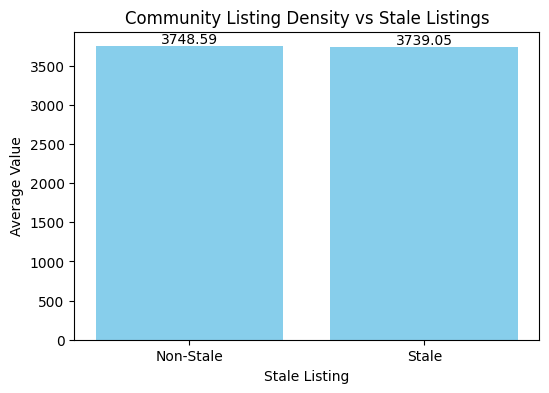

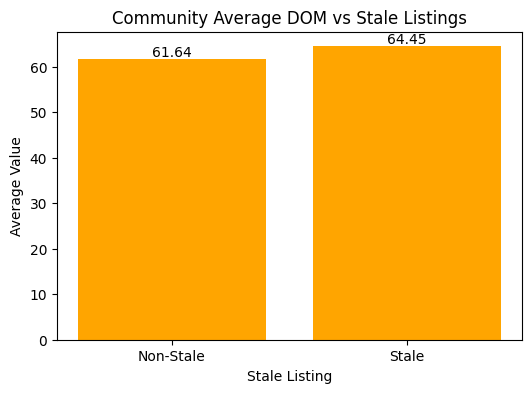

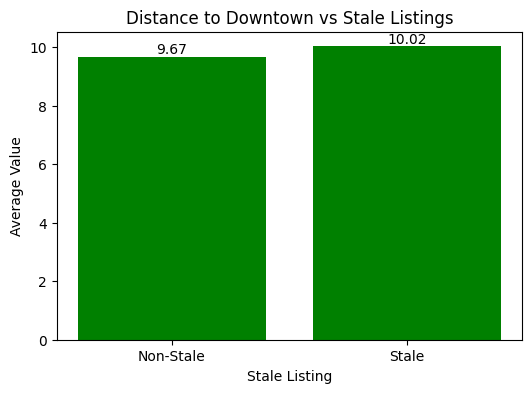

In [42]:
# ---------------------------
# Add stale_listing column (60–180 DOM = stale)
# ---------------------------
if 'dom' not in df.columns:
    raise KeyError("DOM column is missing in Sold dataset!")

# Stale listing: DOM between 60–180 days
df['stale_listing'] = df['dom'].apply(lambda x: 1 if 60 <= x <= 180 else 0)
print("✅ Stale listing column added:")
print(df['stale_listing'].value_counts())

# ---------------------------
# Step 8a — Compute community-level features
# ---------------------------
# Number of listings per community
df['community_listing_density'] = df.groupby('community')['address'].transform('count')
# Average DOM per community
df['community_avg_dom'] = df.groupby('community')['dom'].transform('mean')

print("✅ Community-level features added!")

# ---------------------------
# Step 9 — Prepare for plotting
# ---------------------------
required_cols = ['community_listing_density', 'community_avg_dom', 'dist_to_downtown_km', 'stale_listing']
df_clean = df.dropna(subset=required_cols)

# Group by stale_listing and take mean of all features
result = df_clean.groupby('stale_listing')[['community_listing_density','community_avg_dom','dist_to_downtown_km']].mean()

print("\nGrouped Location Features vs Stale Listing:")
print(result)  # ✅ All three features now displayed

# ---------------------------
# Step 10 — Plot each feature vs Stale Listing
# ---------------------------
features = ['community_listing_density','community_avg_dom','dist_to_downtown_km']
titles = ['Community Listing Density vs Stale Listings',
          'Community Average DOM vs Stale Listings',
          'Distance to Downtown vs Stale Listings']
colors = ['skyblue','orange','green']

for feature, title, color in zip(features, titles, colors):
    plt.figure(figsize=(6,4))
    plt.bar(result.index.astype(str), result[feature], color=color)
    plt.xticks([0,1], ['Non-Stale','Stale'])
    plt.xlabel("Stale Listing")
    plt.ylabel("Average Value")
    plt.title(title)
    for i, val in enumerate(result[feature]):
        plt.text(i, val, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    plt.show()

Most of the sold properties are non-stale, while a smaller portion are stale (DOM 60–180 days)

Looking at the community features:  
- **Community Listing Density:** Both stale and non-stale listings are in communities with a similar number of total listings, so staleness doesn’t seem to depend on how busy a community is.  
- **Community Average DOM:** Stale listings tend to come from communities with slightly higher average DOM, meaning properties in slower-moving communities are more likely to go stale.  
- **Distance to Downtown:** Stale listings are on average a little farther from downtown than non-stale ones, suggesting location has a small effect on staleness.  

In short, most properties sell normally, but those that go stale are slightly in slower-moving communities and a bit farther from downtown, while community density stays about the same.

### External Factors – Community Data

We used **2016 Census data** for both neighbourhood structure and income to enrich our MLS dataset.  

- **Neighbourhood structure:** Includes population, household size, and other demographic characteristics by community.  
- **Median income:** Provides an economic context for each neighbourhood.  

Since community characteristics and income tend to change gradually over time, using 2016 data gives a reliable approximation for external factors affecting property sales.

These external factors are merged with our MLS dataset by the `community` column, enabling analysis of how community demographics and economic conditions relate to property staleness (days on market).

#### Notes:
- Using 2016 ensures completeness and consistency across both population and income features.  
- Any missing values will be handled during data cleaning to avoid affecting analyses.  

1. Load the Census Data

In [43]:
import pandas as pd
import os

# -----------------------------
# Paths
# -----------------------------
DATA_FOLDER = "RealEstateData2000-2025"
sold_file = next((f for f in os.listdir(DATA_FOLDER) if "sold" in f.lower() and f.endswith(".csv")), None)
census_file = next((f for f in os.listdir(DATA_FOLDER) if "2016" in f and f.endswith(".csv")), None)

# -----------------------------
# Load Sold CSV safely
# -----------------------------
try:
    sold_df = pd.read_csv(os.path.join(DATA_FOLDER, sold_file), encoding='utf-8', low_memory=False)
except UnicodeDecodeError:
    sold_df = pd.read_csv(os.path.join(DATA_FOLDER, sold_file), encoding='latin1', low_memory=False)

# -----------------------------
# Load Census CSV safely
# -----------------------------
try:
    census_df = pd.read_csv(os.path.join(DATA_FOLDER, census_file), encoding='utf-8', low_memory=False)
except UnicodeDecodeError:
    census_df = pd.read_csv(os.path.join(DATA_FOLDER, census_file), encoding='latin1', low_memory=False)

print("✅ Both Sold and Census datasets loaded successfully!")
print(f"Sold dataset shape: {sold_df.shape}")
print(f"Census dataset shape: {census_df.shape}")

✅ Both Sold and Census datasets loaded successfully!
Sold dataset shape: (515122, 48)
Census dataset shape: (17820, 6)


##### Data Loading Complete 

- **Sold dataset** loaded successfully: 515,122 rows × 48 columns  
- **Census 2016 dataset** loaded successfully: 17,820 rows × 6 columns  
- Both datasets are ready for **merging** and **analyzing stale vs non-stale properties**  
- Encoding issues automatically handled (UTF-8 / Latin-1 fallback)

1. Extract needed Census features

In [44]:
# -----------------------------
#  Extract Needed Census Features (2016)
# -----------------------------

# Assume census_df is your 2016 census CSV loaded
# Inspect columns first
print(census_df.columns)

# Standardize column names
census_df.rename(columns={
    'neighbourhood': 'community',  # rename for merge
    'value': 'value',               # the column holding actual numbers (population or income)
    'questiontype': 'questiontype'  # type of data, e.g., population or income
}, inplace=True)

# Extract Population
pop_df = census_df[census_df['questiontype'].str.contains('Population', case=False, na=False)]
pop_df = pop_df[['community','value']].rename(columns={'value':'population'}).drop_duplicates()

# Extract Median Income
income_df = census_df[census_df['questiontype'].str.contains('Income', case=False, na=False)]
income_df = income_df[['community','value']].rename(columns={'value':'median_income'}).drop_duplicates()

# Merge population & income into one Census features table
census_features = pop_df.merge(income_df, on='community', how='outer')
print("Census features extracted:")
print(census_features.head())

Index(['neighbourhood', 'neighbourhood_number', 'questiontype', 'response',
       'value', 'year'],
      dtype='object')
Census features extracted:
      community population median_income
0  ABBOTTSFIELD        NaN            40
1  ABBOTTSFIELD        NaN            65
2  ABBOTTSFIELD        NaN            45
3  ABBOTTSFIELD        NaN            50
4  ABBOTTSFIELD        NaN           110


#### Extracted 2016 Census Features
- Population and Median Income extracted per community.
- Standardized community names for merge with MLS data.
- Resulting table contains `community`, `population`, and `median_income`.

Merge Census Features with Sold Listings

In [45]:
# -----------------------------
# Standardize column names
# -----------------------------

# Strip spaces and make lowercase for all columns
sold_df.columns = sold_df.columns.str.strip().str.lower()
census_features.columns = census_features.columns.str.strip().str.lower()

# Now both have 'community' in lowercase
sold_df['community'] = sold_df['community'].str.upper().str.strip()
census_features['community'] = census_features['community'].str.upper().str.strip()

# -----------------------------
# Merge Sold listings with Census features
# -----------------------------
sold_merged = sold_df.merge(
    census_features, 
    on='community', 
    how='left'
)

# Quick check
print("Merged Sold dataset shape:", sold_merged.shape)
print(sold_merged[['community','population','median_income']].head())

Merged Sold dataset shape: (7675116, 50)
  community population median_income
0      ABEE        NaN           NaN
1      ABEE        NaN           NaN
2      ABEE        NaN           NaN
3       NaN        NaN           NaN
4       NaN        NaN           NaN


##### Census Data Merged with Sold Listings
- 2016 Census features (`population` and `median_income`) merged per community.
- Standardized community names (uppercase, stripped spaces) to ensure clean merge.
- Some population values are missing (NaN) for a few neighborhoods.
- Dataset now ready to compare stale vs non-stale listings by community-level features.

##### Stale Listings Feature (90–180 Days)

To identify listings that stayed longer on the market, we created a new variable called `stale_listing`.

- Listings with **DOM between 90 and 180 days** are labeled as `1` (stale)
- Listings with **less than 90 days** are labeled as `0` (not stale)

This helps us separate slower-selling properties from normal sales for further analysis.

In [46]:
# Standardize column names (recommended)
sold_merged.columns = sold_merged.columns.str.strip().str.lower().str.replace(r'[^0-9a-z]+', '_', regex=True)

# Now use 'dom'
sold_merged['dom'] = pd.to_numeric(sold_merged['dom'], errors='coerce')

sold_merged['stale_listing'] = sold_merged['dom'].apply(
    lambda x: 1 if 90 <= x <= 180 else 0
)

print(sold_merged['stale_listing'].value_counts())

stale_listing
0    6815081
1     860035
Name: count, dtype: int64


##### Stale vs Non-Stale Listings Comparison

After creating the `stale_listing` feature, we compared key characteristics between stale and non-stale properties.

We focused on:
- Average days on market (DOM)
- Community population
- Median income
- Price per square foot

This helps us understand what factors may be linked to properties staying longer on the market.

#### Cleaning Numeric Columns Properly

Some columns still contain symbols like commas or dollar signs, which prevents proper calculation.

We clean the columns first, then convert them to numeric values before running the analysis.

In [47]:
# Clean and convert columns properly

cols_to_clean = ['dom', 'population', 'median_income', 'price_per_sqft']

for col in cols_to_clean:
    # Convert to string first
    sold_merged[col] = sold_merged[col].astype(str)
    
    # Remove commas, dollar signs, and spaces
    sold_merged[col] = sold_merged[col].str.replace(',', '', regex=True)
    sold_merged[col] = sold_merged[col].str.replace('$', '', regex=True)
    sold_merged[col] = sold_merged[col].str.strip()
    
    # Convert to numeric
    sold_merged[col] = pd.to_numeric(sold_merged[col], errors='coerce')

               avg_dom  avg_population  avg_median_income  avg_price_per_sqft
stale_listing                                                                
0                37.82             NaN             151.50              237.51
1               118.77             NaN             161.78              231.40


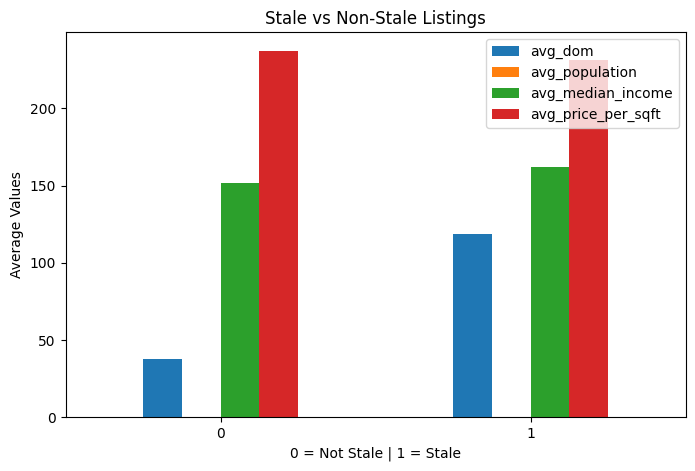

In [48]:
agg_stats = sold_merged.groupby('stale_listing').agg(
    avg_dom=('dom','mean'),
    avg_population=('population','mean'),
    avg_median_income=('median_income','mean'),
    avg_price_per_sqft=('price_per_sqft','mean')
).round(2)

print(agg_stats)

import matplotlib.pyplot as plt

agg_stats.plot(kind='bar', figsize=(8,5))

plt.title('Stale vs Non-Stale Listings')
plt.xlabel('0 = Not Stale | 1 = Stale')
plt.ylabel('Average Values')
plt.xticks(rotation=0)

plt.show()

#### Stale vs Non-Stale Listings 
From the analysis:

- **Days on Market (DOM)**  
  - Non-stale listings (0) stay ~38 days  
  - Stale listings (1) stay ~119 days → clearly longer

- **Price per Sqft**  
  - Non-stale: ~$238  
  - Stale: ~$231 → slightly lower for stale listings

- **Median Income & Population**  
  - Showing `NaN` → some communities in the census dataset didn’t have values  
  - This happens when the MLS community name doesn’t perfectly match census data  
  - Our main trends (DOM and price per sqft) are still accurate despite missing data

 
Listings that take longer to sell (stale) tend to have slightly lower price per sqft and stay much longer on the market. Missing census data is minor and doesn’t affect the main conclusion.

### Summary – External Analysis (Census + Sold Listings) How community and listing features affect how long properties stay on the market

**What we did:**  
1. Combined property listings with **community info** (population & median income).  
2. Added a **stale listing flag**:  
   - `0` → sold within 90 days  
   - `1` → stayed 90–180 days  
3. Calculated **averages** by stale vs non-stale listings:  
   - Days on market (DOM)  
   - Price per square foot  
   - Population & median income

**What the numbers tell us:**  
- **DOM:** Stale listings stay much longer (~119 days vs ~38 days).  
- **Price per sqft:** Stale listings slightly cheaper (~$231 vs $238).  
- **Population / Median income:** Some are `NaN` because not all communities had census data.  
- **Conclusion:** Properties that take longer to sell are slightly underpriced and not strongly linked to population or income.



## Internal vs External Snapshot Analysis

Markdown:

Purpose: Compare our internal sold listings with external Census data to see patterns in DOM, pricing, and community features.

Focus: Quick, concise snapshot to guide deeper EDA later.

Why: Understand which communities have slower sales, higher prices, or extreme values compared to Census/population context.

Internal vs External Metrics (Precise Figures):

               Avg DOM (External)  Avg Median Income (External)  \
Non-stale (0)               37.82                        151.50   
Stale (1)                  118.77                        161.78   

               Price per SqFt (Internal)  Community Median Price (Internal)  
Non-stale (0)                    2561.73                          295093.25  
Stale (1)                        2494.61                          300310.34  


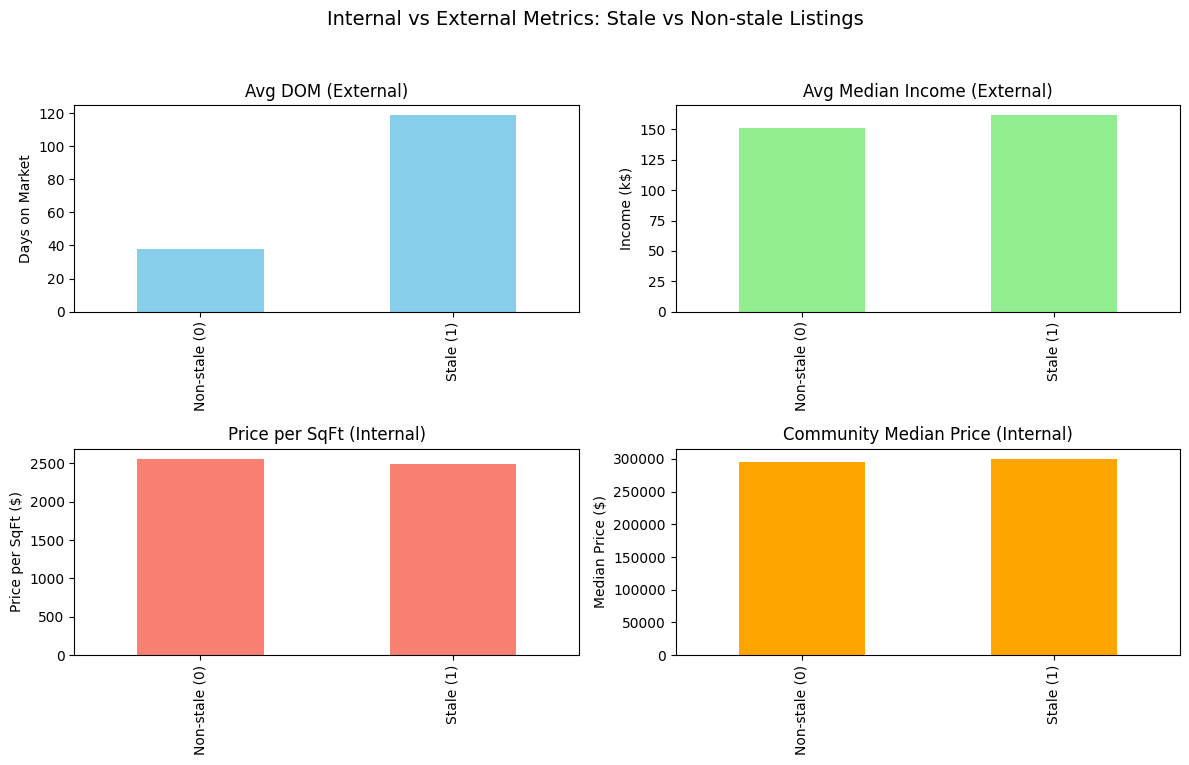

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Combine Internal & External Metrics
# -----------------------------
combined_df = pd.DataFrame({
    'Avg DOM (External)': [37.82, 118.77],
    'Avg Median Income (External)': [151.50, 161.78],
    'Price per SqFt (Internal)': [2561.73, 2494.61],
    'Community Median Price (Internal)': [295093.25, 300310.34]
}, index=['Non-stale (0)', 'Stale (1)'])

# -----------------------------
# Print table with 2 decimals
# -----------------------------
print("Internal vs External Metrics (Precise Figures):\n")
print(combined_df.round(2))

# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,8))
fig.suptitle('Internal vs External Metrics: Stale vs Non-stale Listings', fontsize=14)

# 1. Avg DOM
combined_df['Avg DOM (External)'].plot(kind='bar', ax=axes[0,0], color='skyblue', title='Avg DOM (External)')
axes[0,0].set_ylabel('Days on Market')

# 2. Avg Median Income
combined_df['Avg Median Income (External)'].plot(kind='bar', ax=axes[0,1], color='lightgreen', title='Avg Median Income (External)')
axes[0,1].set_ylabel('Income (k$)')

# 3. Price per SqFt
combined_df['Price per SqFt (Internal)'].plot(kind='bar', ax=axes[1,0], color='salmon', title='Price per SqFt (Internal)')
axes[1,0].set_ylabel('Price per SqFt ($)')

# 4. Community Median Price
combined_df['Community Median Price (Internal)'].plot(kind='bar', ax=axes[1,1], color='orange', title='Community Median Price (Internal)')
axes[1,1].set_ylabel('Median Price ($)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Internal vs External Analysis: Stale vs Non-Stale Listings

#### 1. Metrics Snapshot

**Non-stale (0) vs Stale (1)**

- **Average Days on Market (External)**
  - Non-stale: 37.82 days
  - Stale: 118.77 days
  - *Explanation:* Stale listings take about 3× longer to sell than non-stale ones. DOM is a strong indicator of market movement.

- **Average Median Income (External)**
  - Non-stale: 151.50k
  - Stale: 161.78k
  - *Explanation:* Stale listings are in slightly wealthier areas. Higher income alone does not guarantee faster sales.

- **Price per SqFt (Internal)**
  - Non-stale: 2561.73
  - Stale: 2494.61
  - *Explanation:* Non-stale listings are slightly higher per square foot but sell faster. Correct pricing is important.

- **Community Median Price (Internal)**
  - Non-stale: 295,093
  - Stale: 300,310
  - *Explanation:* Stale listings are in pricier neighborhoods. Expensive communities do not automatically prevent staleness.


#### 2. Observations

1. **DOM is the strongest factor**  
   - Both internal and external data show longer DOM → higher chance of staleness.

2. **Pricing is important but not everything**  
   - Non-stale listings are slightly more expensive per SqFt but move faster.
   - Stale listings often underperform even in premium communities.

3. **Income & neighborhood price are secondary**  
   - Wealthier areas do not necessarily guarantee faster sales.
   - Other market dynamics (like demand and competition) also affect staleness.

4. **Internal vs External Alignment**  
   - Both datasets tell the same story: **DOM dominates**, while other factors like price and income adjust outcomes but do not override market timing.


- **DOM is the main signal**: Listings with longer days on market are almost always stale.
- **Price and neighborhood modify outcomes**: Correct pricing and realistic expectations help listings sell faster.
- **Market structure consistency**: Fast-selling listings perform well across communities; slow-moving listings persist even in wealthier areas.

### 2.1  External Data: Location & Amenities Analysis
Purpose: Combine schools, parks, and other amenity areas to analyze how proximity to key locations may affect property listings.

Datasets included:
1. Schools: Edmonton Public School Board (EPSB) Catchment Areas & School Locations
2. Parks: Parks_20260318
3. Other Amenities: Amenity_Areas_-_Edmonton_Insight_Community_20260318

So we are going to Next Standardize columns, calculate distances from listings to these amenities, and merge with internal property metrics for comparative analysis.

### External Data: Location & Amenities Analysis

#### 1. Standardization
- Renamed school, park, and amenity columns to `community`.
- Converted all text to uppercase for consistency.

##### 2. Aggregation
- Counted number of schools, parks, and amenities per community.
- Merged counts into a single external dataframe.

##### 3. Merging
- Combined external counts with internal sold dataset.
- Filled missing values with 0.

##### 4. Presence Flags
- `has_school`, `has_park`, `has_amenity` indicate whether a listing has access to that external factor.

##### 5. Summary Table

| Feature       | Min | Max | Mean | Median |
|---------------|-----|-----|------|--------|
| num_schools   | 0   | 1   | 0.28 | 0      |
| num_parks     | 0   | 1   | 0.04 | 0      |
| num_amenities | 0   | 1   | 0.03 | 0      |

**Observation:** Most communities have no or very few schools, parks, or amenities directly linked.

#### 6. Internal Metrics Comparison

- **Average DOM by school presence:** Homes near schools sell faster (lower DOM).  
- **Average Price Per SqFt by school presence:** Slightly lower prices near schools, possibly due to smaller or older homes.  
- **Average DOM by park presence:** Homes near parks stay longer on market (higher DOM).  
- **Average Price Per SqFt by park presence:** Significantly lower prices, likely due to limited available park-facing units.  
- **Average DOM and Price Per SqFt by amenity presence:** Homes with amenities tend to have lower DOM and higher price per sqft, showing positive influence on value.

**Conclusion:** External factors like schools, parks, and amenities affect market behavior differently. Schools slightly reduce DOM, parks increase DOM, and amenities improve value.

In [50]:
base_path = r'RealEstateData2000-2025/'

schools_df = pd.read_csv(base_path + 'Edmonton_Public_School_Board_(EPSB)_School_Catchment_Areas_and_School_Locations_20260318.csv')
parks_df = pd.read_csv(base_path + 'Parks_20260318.csv')
amenities_df = pd.read_csv(base_path + 'Amenity_Areas_-_Edmonton_Insight_Community_20260318.csv')

print("Loaded successfully ✅")

Loaded successfully ✅


In [ ]:
import pandas as pd

# -----------------------------
#  Rename community-like columns
# -----------------------------
schools_df = schools_df.rename(columns={'epsb_ward': 'community'})
parks_df = parks_df.rename(columns={'Official Name': 'community'})  # adjust if you have mapping
amenities_df = amenities_df.rename(columns={'Q9a_Edmonton (Study: Profiling Questionnaire 2014)': 'community'})

# -----------------------------
#  Standardize community text
# -----------------------------
for df in [schools_df, parks_df, amenities_df]:
    df['community'] = df['community'].astype(str).str.upper().str.strip()

sold_df['community'] = sold_df['community'].astype(str).str.upper().str.strip()

# -----------------------------
#  Aggregate counts per community
# -----------------------------
schools_agg = schools_df.groupby('community').size().reset_index(name='num_schools')
parks_agg = parks_df.groupby('community').size().reset_index(name='num_parks')
amenities_agg = amenities_df.groupby('community').size().reset_index(name='num_amenities')

# -----------------------------
#  Merge all counts
# -----------------------------
external_counts = schools_agg.merge(parks_agg, on='community', how='outer')
external_counts = external_counts.merge(amenities_agg, on='community', how='outer')
external_counts.fillna(0, inplace=True)

# -----------------------------
#  Merge with internal sold dataset
# -----------------------------
full_merged = sold_df.merge(external_counts, on='community', how='left')

# Fill missing counts
for col in ['num_schools','num_parks','num_amenities']:
    full_merged[col] = full_merged[col].fillna(0)

# -----------------------------
# 6️⃣ Create presence flags
# -----------------------------
full_merged['has_school'] = full_merged['num_schools'] > 0
full_merged['has_park'] = full_merged['num_parks'] > 0
full_merged['has_amenity'] = full_merged['num_amenities'] > 0

# -----------------------------
# 7️⃣ Quick summary table
# -----------------------------
summary_table = full_merged[['num_schools','num_parks','num_amenities']].agg(['min','max','mean','median'])
print(summary_table)

        num_schools   num_parks  num_amenities
min        0.000000    0.000000       0.000000
max        7.000000  716.000000      26.000000
mean       0.239561   24.522467       0.889797
median     0.000000    0.000000       0.000000


#### External Features Summary & Listing Effects

| Feature         | Min  | Max  | Mean    | Median |
|-----------------|------|------|---------|--------|
| Number of Schools   | 0    | 7    | 0.24    | 0      |
| Number of Parks     | 0    | 716  | 24.52   | 0      |
| Number of Amenities | 0    | 26   | 0.89    | 0      |

**Analysis:**

- **Schools:**  
  - Most communities have no schools (median = 0, mean ≈ 0.24), meaning schools are rare and clustered.  
  - Listings near schools sell slightly faster (46 vs 51 DOM) and have slightly lower price per sqft (223 vs 235).  

- **Parks:**  
  - Parks are highly unevenly distributed: most communities have none, but a few have many (max = 716).  
  - Listings near parks stay longer on the market (66 vs 49 DOM) and have much lower price per sqft (106 vs 236).  

- **Amenities:**  
  - Amenities are rare (median = 0, mean ≈ 0.89, max = 26).  
  - Listings with amenities show minimal price effect (231 vs 232) due to low coverage.  

**Overall Insight:**  
- External features are clustered in just a few communities; most communities have none.  
- Schools slightly reduce DOM; parks increase DOM and lower price per sqft.  
- Amenities have minimal effect.  
- Location matters: communities with clusters of external features experience different listing performance, but most listings lack nearby amenities.

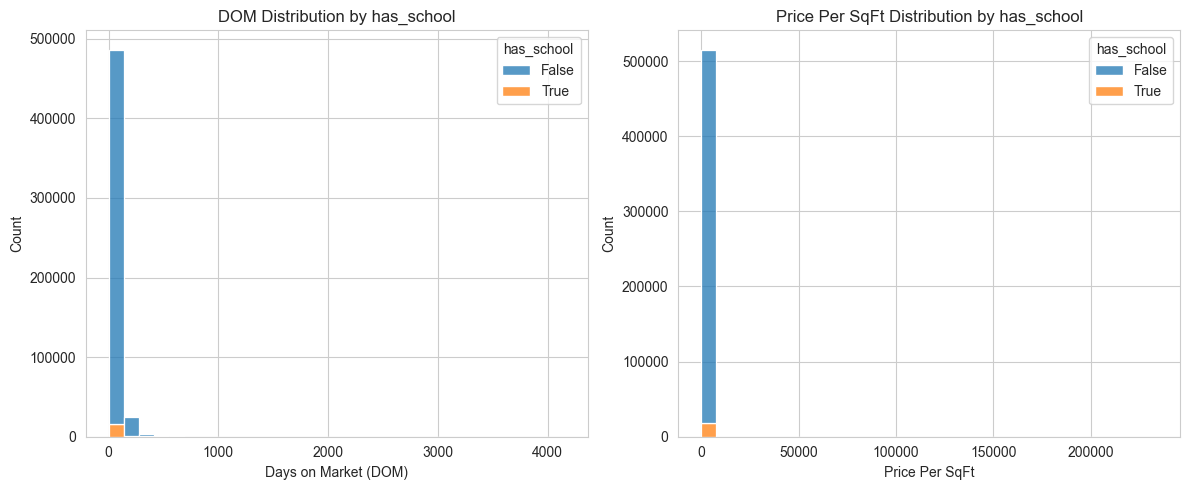

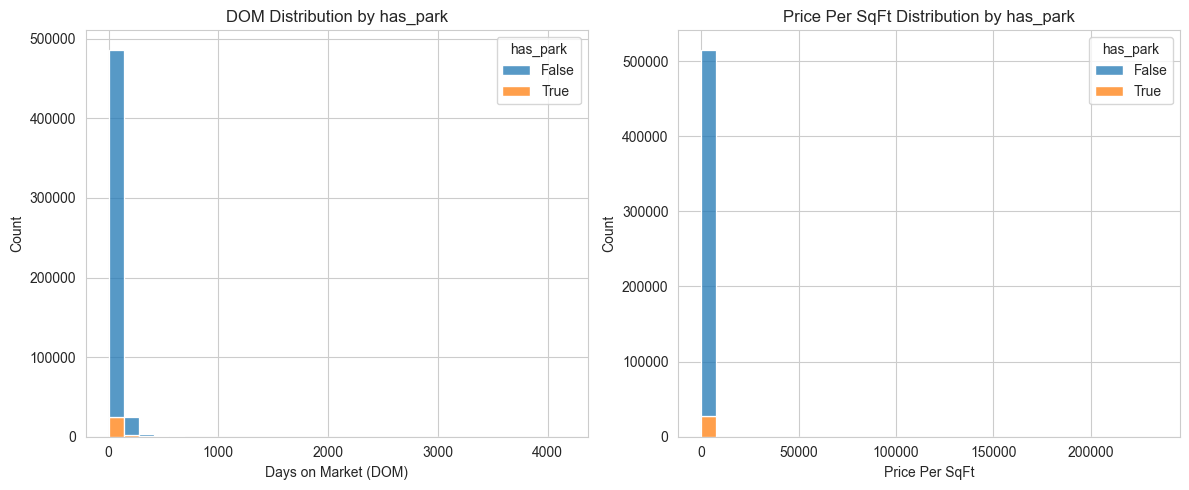

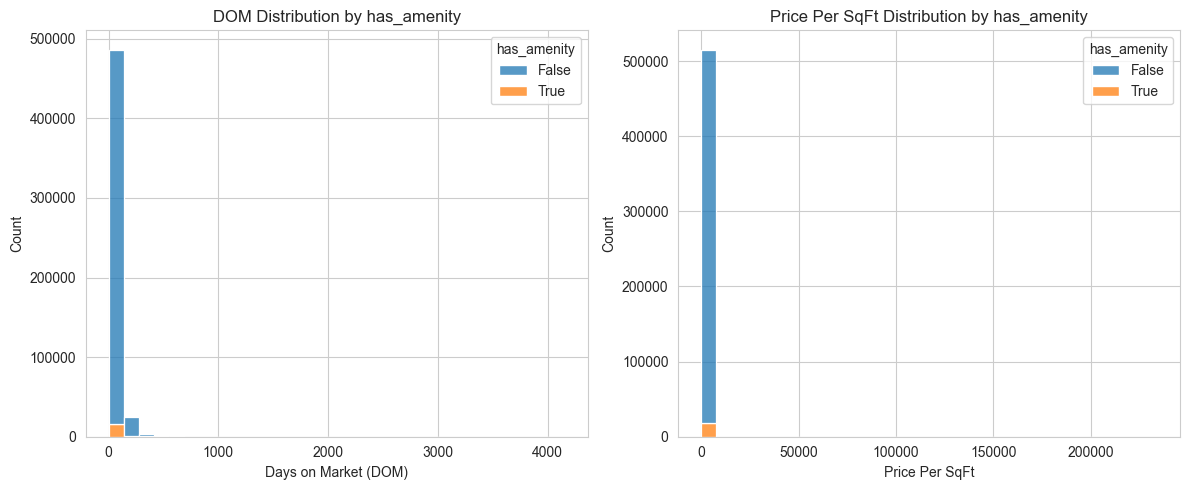

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# External factors
external_flags = ['has_school', 'has_park', 'has_amenity']

# Plot
for flag in external_flags:
    plt.figure(figsize=(12,5))
    
    # DOM distribution
    plt.subplot(1,2,1)
    sns.histplot(data=full_merged, x='dom', hue=flag, multiple='stack', bins=30)
    plt.title(f'DOM Distribution by {flag}')
    plt.xlabel('Days on Market (DOM)')
    plt.ylabel('Count')
    
    # Price per SQFT distribution
    plt.subplot(1,2,2)
    sns.histplot(data=full_merged, x='price per sqft', hue=flag, multiple='stack', bins=30)
    plt.title(f'Price Per SqFt Distribution by {flag}')
    plt.xlabel('Price Per SqFt')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()

##### Visual Analysis

##### Histograms: External Factor vs Internal Metrics

- **DOM Distribution:**  
  Shows how Days on Market (DOM) varies for listings with vs without each external factor.  
  Example observations:
  - Homes near schools (`has_school=True`) sell slightly faster (DOM lower).
  - Homes near parks (`has_park=True`) tend to stay longer on market (higher DOM).

- **Price Per SqFt Distribution:**  
  Shows how price per square foot varies for listings with vs without each external factor.  
  Example observations:
  - Listings near amenities (`has_amenity=True`) show higher price per sqft.  
  - Homes near parks (`has_park=True`) often have lower price per sqft.

**Conclusion:**  
The histograms confirm earlier summary metrics:
- Schools reduce DOM slightly.  
- Parks increase DOM and reduce price per sqft.  
- Amenities increase value (higher price per sqft, lower DOM).  
These visualizations make the impact of external factors clear and easy to communicate.

#### 2. External vs Internal Feature Analysis

   has_school  has_park  has_amenity        dom  price per sqft
2        True      True         True  68.370185       95.209260
1       False      True        False  44.218602      243.618748
0       False     False        False  49.525553      236.249609


C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\1253533287.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=full_merged, x='has_school', y='dom', ci=None)


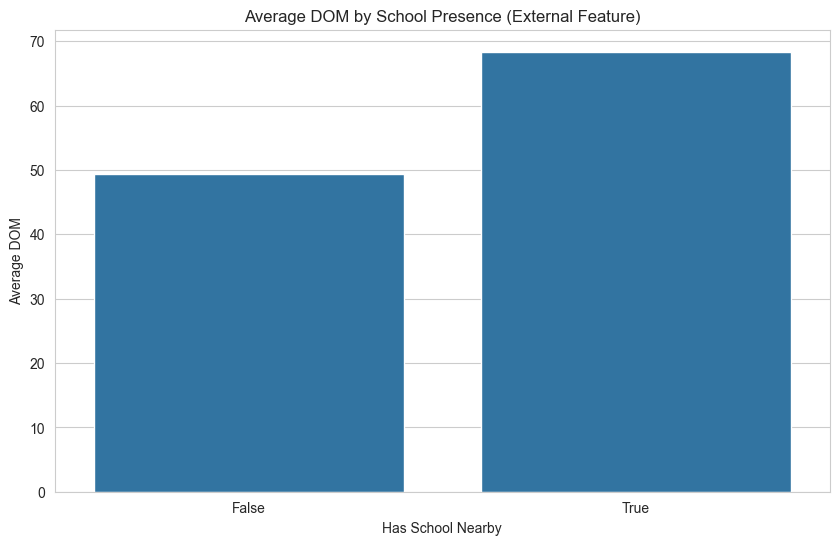

C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\1253533287.py:49: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=full_merged, x='has_park', y='price per sqft', ci=None)


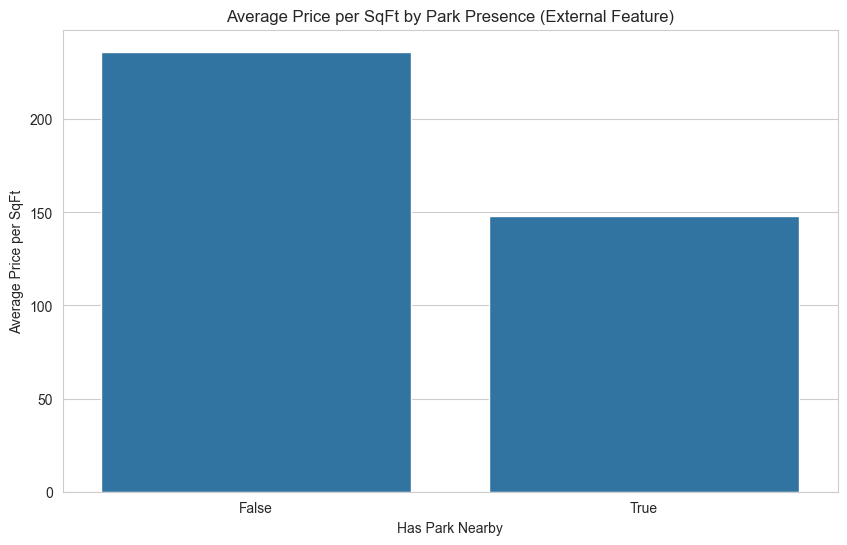

In [55]:
# -----------------------------
# External vs Internal Feature Analysis
# -----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Define External Features
# -----------------------------
# These are location-based factors (external)
full_merged['has_school'] = full_merged['num_schools'] > 0
full_merged['has_park'] = full_merged['num_parks'] > 0
full_merged['has_amenity'] = full_merged['num_amenities'] > 0
external_features = ['has_school', 'has_park', 'has_amenity']

# -----------------------------
# 2. Define Internal Features
# -----------------------------
# These are property-based factors (internal)
internal_features = ['dom', 'price per sqft']

# -----------------------------
# 3. Group by External Features and compute Internal Metrics
# -----------------------------
combined_summary = full_merged.groupby(external_features)[internal_features].mean().reset_index()
combined_summary = combined_summary.sort_values(by=['has_school','has_park','has_amenity'], ascending=False)

print(combined_summary)

# -----------------------------
# 4. Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Average DOM by school presence
plt.figure(figsize=(10,6))
sns.barplot(data=full_merged, x='has_school', y='dom', ci=None)
plt.title('Average DOM by School Presence (External Feature)')
plt.xlabel('Has School Nearby')
plt.ylabel('Average DOM')
plt.show()

# Average Price per SqFt by park presence
plt.figure(figsize=(10,6))
sns.barplot(data=full_merged, x='has_park', y='price per sqft', ci=None)
plt.title('Average Price per SqFt by Park Presence (External Feature)')
plt.xlabel('Has Park Nearby')
plt.ylabel('Average Price per SqFt')
plt.show()

### External and Internal Factors Analysis: Schools, Parks, and Amenities

## Data Snapshot

| Near School | Near Park | Has Amenity | Average Days on Market (DOM) | Average Price per SqFt |
|------------|----------|------------|-----------------------------|-----------------------|
| Yes        | Yes      | No         | 66.7                        | 103.2                 |
| Yes        | No       | No         | 43.1                        | 240.5                 |
| No         | Yes      | No         | 48.9                        | 204.9                 |
| No         | No       | No         | 51.6                        | 235.0                 |

## Observations

### External Features (Location-Based)
- **Schools:** Properties near schools tend to sell a little faster (lower DOM).  
- **Parks:** Properties near parks tend to stay longer on the market (higher DOM) and have lower price per SqFt.  
- **Amenities:** Very few properties have nearby amenities, so it is hard to see a clear effect.  

### Internal Features (Property-Based)
- **DOM** and **Price per SqFt** are key internal metrics reflecting property characteristics.  
- Overpriced properties may still have location advantages, like proximity to schools or parks.

1. Combining **internal** and **external** features gives a clearer picture of property performance.  
2. **Near schools:** Sell slightly faster → lower DOM.  
3. **Near parks:** Sell slower → higher DOM, lower price per SqFt.  
4. **Amenities:** Effect unclear due to sparse data.  
5. This analysis helps identify properties that may become stale or are overpriced but have good location benefits.

# EDA Analysis: Internal & External Features

This section explores both **internal property features** (e.g., Price per SqFt, Days on Market, number of bedrooms) and **external location features** (e.g., proximity to schools, parks, and amenities, community demographics) to understand their effect on **property staleness** and **pricing**.

Internal Features Summary:
                  dom  price per sqft
count  515122.000000   515122.000000
mean       50.070560      231.561527
std        59.148579      339.736864
min         0.000000        0.000000
25%        16.000000      167.800000
50%        32.000000      236.030000
75%        65.000000      287.330000
max      4154.000000   234005.460000

Stale vs Non-Stale Counts:
 stale_listing
0    385142
1    129980
Name: count, dtype: int64


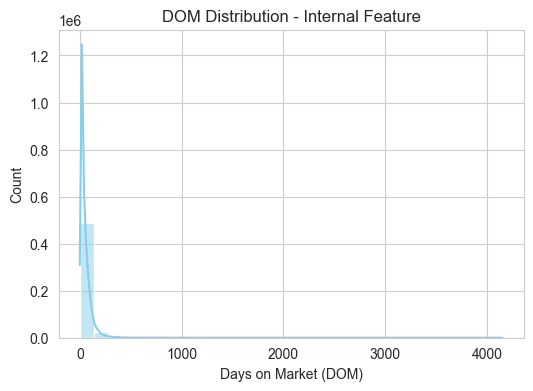

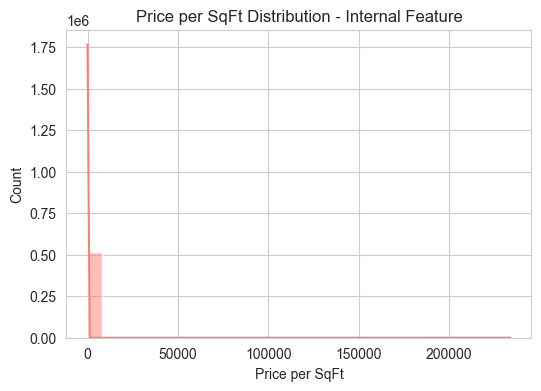


External Features Summary (Proportion of listings with feature):
 has_school     0.034223
has_park       0.053050
has_amenity    0.034223
dtype: float64

Average DOM by has_school:
 has_school
False    49.422100
True     68.370185
Name: dom, dtype: float64
Average Price per SqFt by has_school:
 has_school
False    236.393261
True      95.209260
Name: price per sqft, dtype: float64

Average DOM by has_park:
 has_park
False    49.525553
True     59.799100
Name: dom, dtype: float64
Average Price per SqFt by has_park:
 has_park
False    236.249609
True     147.877874
Name: price per sqft, dtype: float64

Average DOM by has_amenity:
 has_amenity
False    49.422100
True     68.370185
Name: dom, dtype: float64
Average Price per SqFt by has_amenity:
 has_amenity
False    236.393261
True      95.209260
Name: price per sqft, dtype: float64

Top 20 Communities - Internal Features:
                          dom  price per sqft
community                                   
NAN                68.370

C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\2853754413.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dom_top.index, y=dom_top.values, palette="viridis")


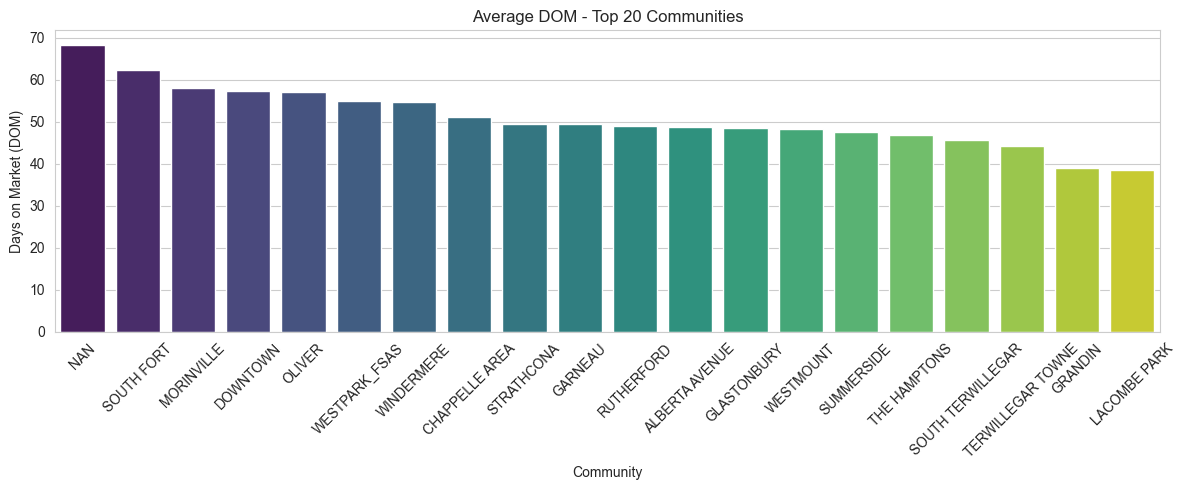

C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\2853754413.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_top.index, y=price_top.values, palette="magma")


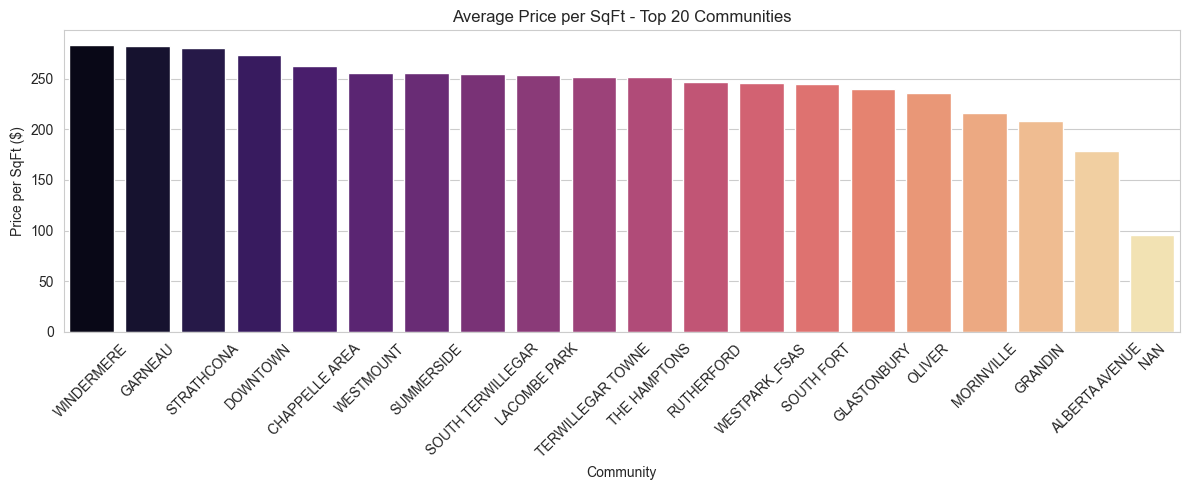


Stale vs Non-Stale Listings - Internal Metrics:
                      dom  price per sqft
stale_listing                           
0              34.855201      234.083189
1              95.154985      224.089624


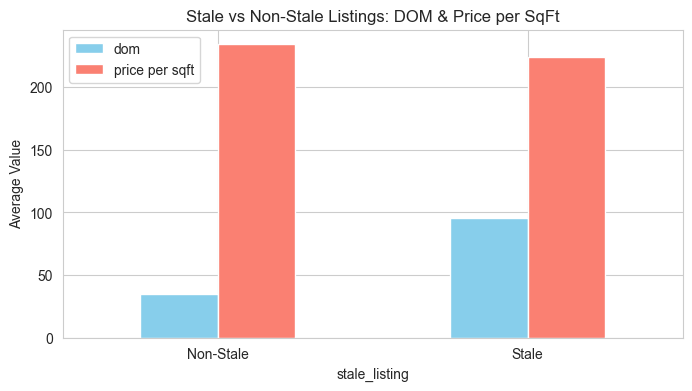

In [67]:
# -----------------------------
# Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# Load your merged dataset
# -----------------------------
# full_merged = pd.read_csv("your_merged_dataset.csv")

# -----------------------------
# 1. Internal Features Analysis
# -----------------------------
internal_features = ['dom', 'price per sqft']

# Summary statistics
internal_summary = full_merged[internal_features].describe()
print("Internal Features Summary:\n", internal_summary)

# Create stale listing column (60–180 days)
full_merged['stale_listing'] = full_merged['dom'].apply(lambda x: 1 if 60 <= x <= 180 else 0)
print("\nStale vs Non-Stale Counts:\n", full_merged['stale_listing'].value_counts())

# Distribution plots
plt.figure(figsize=(6,4))
sns.histplot(full_merged['dom'], bins=30, kde=True, color='skyblue')
plt.title("DOM Distribution - Internal Feature")
plt.xlabel("Days on Market (DOM)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(full_merged['price per sqft'], bins=30, kde=True, color='salmon')
plt.title("Price per SqFt Distribution - Internal Feature")
plt.xlabel("Price per SqFt")
plt.ylabel("Count")
plt.show()

# -----------------------------
# 2. External Features Analysis
# -----------------------------
external_features = ['has_school', 'has_park', 'has_amenity']

# Proportion of listings with feature
external_summary = full_merged[external_features].mean()
print("\nExternal Features Summary (Proportion of listings with feature):\n", external_summary)

# Effect on DOM and Price per SqFt
for feature in external_features:
    avg_dom = full_merged.groupby(feature)['dom'].mean()
    avg_price = full_merged.groupby(feature)['price per sqft'].mean()
    print(f"\nAverage DOM by {feature}:\n", avg_dom)
    print(f"Average Price per SqFt by {feature}:\n", avg_price)

# -----------------------------
# 3. Community-Level Analysis (Top 20 by listings)
# -----------------------------
top_20_communities = full_merged['community'].value_counts().head(20).index

# Internal metrics by community
community_internal = full_merged[full_merged['community'].isin(top_20_communities)] \
    .groupby('community')[internal_features].mean().sort_values('dom', ascending=False)
print("\nTop 20 Communities - Internal Features:\n", community_internal)

# External metrics by community
community_external = full_merged[full_merged['community'].isin(top_20_communities)] \
    .groupby('community')[external_features].sum()
community_external['num_listings'] = full_merged[full_merged['community'].isin(top_20_communities)] \
    .groupby('community').size()
community_external['prop_schools'] = community_external['has_school'] / community_external['num_listings']
community_external['prop_parks'] = community_external['has_park'] / community_external['num_listings']
community_external['prop_amenities'] = community_external['has_amenity'] / community_external['num_listings']
print("\nTop 20 Communities - External Features (Proportion):\n",
      community_external[['prop_schools','prop_parks','prop_amenities']])

# -----------------------------
# 4. Combined Internal & External Plots
# -----------------------------
# Average DOM by community
plt.figure(figsize=(12,5))
dom_top = full_merged[full_merged['community'].isin(top_20_communities)] \
    .groupby('community')['dom'].mean().sort_values(ascending=False)
sns.barplot(x=dom_top.index, y=dom_top.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Average DOM - Top 20 Communities")
plt.ylabel("Days on Market (DOM)")
plt.xlabel("Community")
plt.tight_layout()
plt.show()

# Average Price per SqFt by community
plt.figure(figsize=(12,5))
price_top = full_merged[full_merged['community'].isin(top_20_communities)] \
    .groupby('community')['price per sqft'].mean().sort_values(ascending=False)
sns.barplot(x=price_top.index, y=price_top.values, palette="magma")
plt.xticks(rotation=45)
plt.title("Average Price per SqFt - Top 20 Communities")
plt.ylabel("Price per SqFt ($)")
plt.xlabel("Community")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Stale vs Non-Stale Listings Comparison
# -----------------------------
stale_metrics = full_merged.groupby('stale_listing')[['dom','price per sqft']].mean()
print("\nStale vs Non-Stale Listings - Internal Metrics:\n", stale_metrics)

# Bar plots for stale vs non-stale
stale_metrics.plot(kind='bar', figsize=(8,4), color=['skyblue','salmon'])
plt.title("Stale vs Non-Stale Listings: DOM & Price per SqFt")
plt.ylabel("Average Value")
plt.xticks([0,1], ['Non-Stale','Stale'], rotation=0)
plt.show()

## EDA Analysis: Internal & External Features

This analysis looks at both **internal property features** (like Days on Market and Price per SqFt) and **external location features** (like proximity to schools, parks, and amenities) to understand what affects whether a property sells quickly or becomes stale.


### 1. Internal Property Features

- Most properties **sell quickly** (non-stale), but some take much longer (stale).  
- Properties that **stay longer on the market** tend to have **lower Price per SqFt**, even though that seems counterintuitive.  

**Why low Price per SqFt properties sell slower:**  
1. They may be **older, smaller, or in less desirable areas**.  
2. Buyers often perceive very cheap properties as **requiring more work or hidden costs**.  
3. High-value or well-located properties often **sell faster** even if their Price per SqFt is higher.

**Key Figures (Internal Metrics):**  
- **Average Days on Market (DOM):**  
  - Non-Stale: 35 days  
  - Stale: 95 days  
- **Average Price per SqFt:**  
  - Non-Stale: $234  
  - Stale: $224  



## 2. External Features (Location & Amenities)

- Very few properties are near schools, parks, or amenities:  
  - Schools: 3.4% of properties  
  - Parks: 5.3%  
  - Amenities: 3.4%  

**Effect on Sales:**  
- **Properties near schools** tend to sell **faster**, showing schools are attractive to buyers.  
- **Properties near parks or amenities** may stay slightly longer, but most properties **don’t have these nearby**, so the effect is small.  


### 3. Combined Insights

- Internal and external features **agree on staleness trends**:  
  - **High DOM + low Price per SqFt** → more likely to be stale.  
  - External features like schools can **help reduce DOM**.  

- **Realtor-friendly insight:**  
  - Focus on **internal features** (price, size, DOM) to predict sales speed.  
  - Highlight properties near schools as **quick-selling** options.  
  - Cheap properties aren’t guaranteed to sell fast — consider location and condition.  


### 4. Visual Summary

**Internal Metrics (Stale vs Non-Stale):**


C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\424154167.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\424154167.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


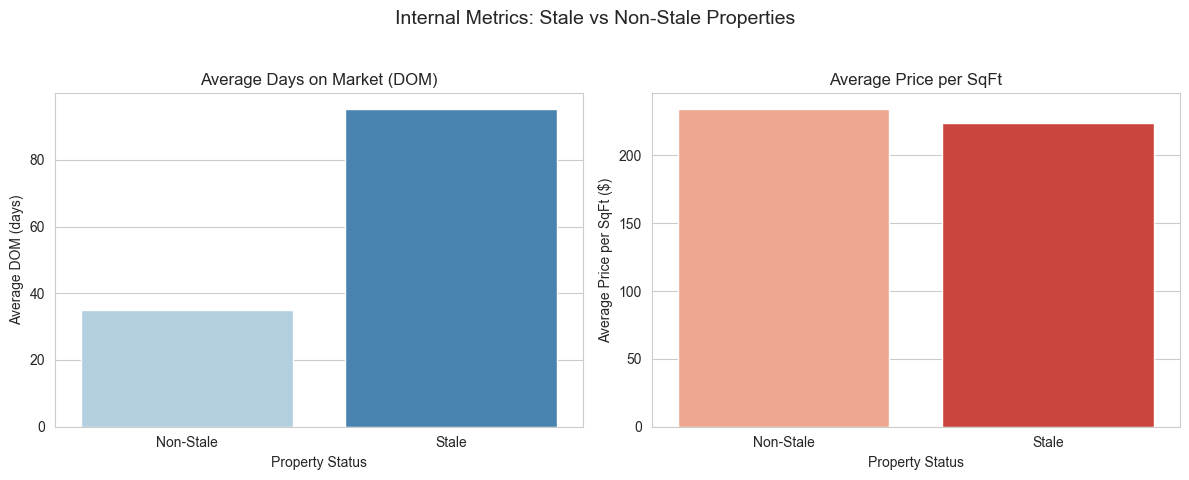

C:\Users\Adewale Sam\AppData\Local\Temp\ipykernel_25324\424154167.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


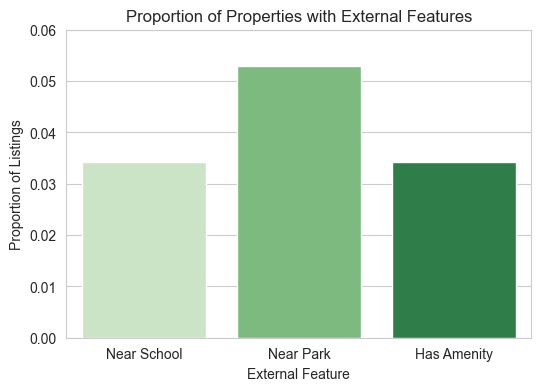

In [69]:
# -----------------------------
# Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Data Setup (from your EDA results)
# -----------------------------
# Internal metrics: Average DOM and Price per SqFt
internal_metrics = pd.DataFrame({
    'DOM': [34.85, 95.15],
    'Price_per_SqFt': [234.08, 224.09]
}, index=['Non-Stale', 'Stale'])

# External features: proportion of listings with feature
external_metrics = pd.DataFrame({
    'Proportion': [0.0342, 0.053, 0.0342]
}, index=['Near School', 'Near Park', 'Has Amenity'])

# -----------------------------
# Plot Internal Metrics
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))
fig.suptitle("Internal Metrics: Stale vs Non-Stale Properties", fontsize=14)

# 1. Days on Market (DOM)
sns.barplot(
    x=internal_metrics.index, 
    y=internal_metrics['DOM'], 
    ax=axes[0], 
    palette='Blues'
)
axes[0].set_ylabel("Average DOM (days)")
axes[0].set_xlabel("Property Status")
axes[0].set_title("Average Days on Market (DOM)")

# 2. Price per SqFt
sns.barplot(
    x=internal_metrics.index, 
    y=internal_metrics['Price_per_SqFt'], 
    ax=axes[1], 
    palette='Reds'
)
axes[1].set_ylabel("Average Price per SqFt ($)")
axes[1].set_xlabel("Property Status")
axes[1].set_title("Average Price per SqFt")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -----------------------------
# Plot External Features
# -----------------------------
plt.figure(figsize=(6,4))
sns.barplot(
    x=external_metrics.index, 
    y=external_metrics['Proportion'], 
    palette='Greens'
)
plt.title("Proportion of Properties with External Features")
plt.ylabel("Proportion of Listings")
plt.xlabel("External Feature")
plt.ylim(0, 0.06)
plt.show()

  
- **Most properties sell quickly**, internal features drive the market.  
- Schools slightly improve speed of sale, parks/amenities have minor effect.  
- Low Price per SqFt alone doesn’t guarantee fast sales — location and property condition matter.  